In [ ]:
import os
import pathlib
import tensorflow as tf
from tensorflow.keras import layers, models, applications
import matplotlib.pyplot as plt

In [ ]:
# 1. CONFIGURATION & PATHS
# ==========================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
# Using a sample dataset path (Replace with your path if needed)
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
# get_file returns the path to the .tar file itself
data_dir_root = pathlib.Path(tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True))
data_dir = pathlib.Path(data_dir_path)

# If the path points to the tar file or a parent, we ensure it points to the folder
if (data_dir_root / 'flower_photos').exists():
    data_dir = data_dir_root / 'flower_photos'
else:
    data_dir = data_dir_root

In [ ]:
# 2. DATA LOADING (The Professional Split)
# ==========================================
# We split here to avoid Data Leakage
train_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_raw.class_names
num_classes = len(class_names)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
# 3. DATA CLEANING & AUGMENTATION PIPELINES
# ==========================================
# Problem 1: Standardizing the math (Rescaling)
preprocessing_pipe = tf.keras.Sequential([
    layers.Resizing(IMG_SIZE[0], IMG_SIZE[1]),
    layers.Rescaling(1./255)
])

# Problem 2: Small dataset fix (Augmentation - ONLY for training)
augmentation_pipe = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

# Applying the pipelines using tf.data for high performance
def prepare_train(ds):
    ds = ds.map(lambda x, y: (augmentation_pipe(preprocessing_pipe(x, training=True), training=True), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

def prepare_val(ds):
    ds = ds.map(lambda x, y: (preprocessing_pipe(x, training=False), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds = prepare_train(train_raw)
val_ds = prepare_val(val_raw)

In [ ]:
# 4. MODEL ARCHITECTURE
# ==========================================
# We use MobileNetV2 - Industry standard for mobile/speed
base_model = applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze the pre-trained weights

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),             # Regularization for stability
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.4991 - loss: 1.2564 - val_accuracy: 0.8161 - val_loss: 0.5341
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.7991 - loss: 0.5703 - val_accuracy: 0.8338 - val_loss: 0.4746
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.8235 - loss: 0.4652 - val_accuracy: 0.8583 - val_loss: 0.4214
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.8557 - loss: 0.3989 - val_accuracy: 0.8692 - val_loss: 0.4052
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.8535 - loss: 0.3957 - val_accuracy: 0.8692 - val_loss: 0.3950
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.8657 - loss: 0.3734 - val_accuracy: 0.8733 - val_loss: 0.3907
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.8690 - loss: 0.3634 - val_accuracy: 0.8665 - val_loss: 0.3929
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.8737 - loss: 0.3481 - val_accuracy: 0.8719 - v

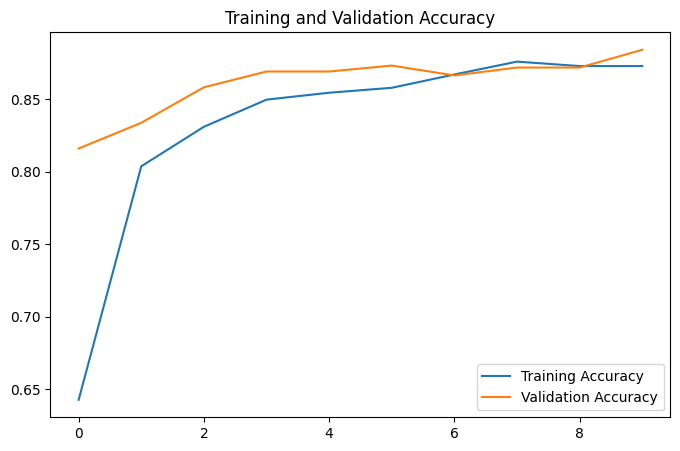

In [ ]:
# 5. TRAINING & EVALUATION
# ==========================================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# --- VISUAL PROOF FOR GITHUB ---
def plot_results(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs_range = range(EPOCHS)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='lower right')
    plt.show()

plot_results(history)